In [1]:
from dotenv import load_dotenv
from langchain_openai.chat_models import ChatOpenAI

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")

In [2]:
from langgraph.graph import MessagesState

class State(MessagesState):
    summary: str

In [3]:
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage, SystemMessage, RemoveMessage

# model node
def call_model(state: State):
    summary = state.get("summary", "")
    if summary:
        sys_msg = f"Summary of the earlier conversation is {summary}"
        messages = [SystemMessage(content=sys_msg)] + state["messages"]
    else:
        messages = state["messages"]
    
    resp = llm.invoke(messages)
    return {"messages": resp}

In [4]:
# summary node
def summarize(state: State):
    summary = state.get("summary", "")
    if summary:
        summary_msg =(f"This is the summary of the conversations: {summary}\n\n"
        "Extend the summary by taking into account the new messages above:")
    else:
        summary_msg = "Create a summary of the above conversation."
    messages = state["messages"] + [HumanMessage(content=summary_msg)]
    resp = llm.invoke(messages)

    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2] if m.id is not None]
    return {"summary": resp.content, "messages": delete_messages}

In [32]:
from langgraph.graph import END
from typing import Literal

# conditional_edge
def should_continue(state: State) -> Literal["summarize", "__end__"]:
    """
    Return the next node to execute.
    """
    messages = state["messages"]
    if len(messages) > 6:
        return "summarize"
    return "__end__"

In [33]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

builder = StateGraph(State)

builder.add_node("call_model", call_model)
builder.add_node("summarize", summarize)

builder.add_edge(START, "call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("summarize", END)

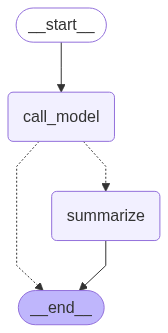

In [34]:
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
from typing import cast
from langchain_core.runnables import RunnableConfig

# Create a thread
config: RunnableConfig = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Lance")
output = graph.invoke(cast(State, {"messages": [input_message]}), config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi, Lance! Good to see you again! What’s on your mind today?


In [41]:
input_message = HumanMessage(content="what's my name?")
output = graph.invoke(cast(State,{"messages": [input_message]}), config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Your name is Lance!


In [42]:
input_message = HumanMessage(content="i like the 49ers!")
output = graph.invoke(cast(State,{"messages": [input_message]}), config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

That's great! The 49ers have a rich history and a strong fan base. Do you have a favorite player on the team?


In [43]:
graph.get_state(config).values.get("summary","")

'In the conversation, Lance introduces himself by stating, "Hi! I\'m Lance." He later asks, "What\'s my name?" to which I respond correctly, affirming his name. This exchange is repeated for emphasis, further reinforcing his name. The conversation primarily centers around his introduction and confirming his identity. Additionally, Lance engages in light banter by greeting me again, reinforcing the friendly tone of our interaction. Throughout the dialogue, there is a playful dynamic as Lance checks in on his name and engages in friendly conversation.'

In [44]:
input_message = HumanMessage(content="i like Nick Bosa, isn't he the highest paid defensive player?")
output = graph.invoke(cast(State,{"messages": [input_message]}), config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Yes, Nick Bosa signed a lucrative contract that made him one of the highest-paid defensive players in the NFL. He's had an impressive career and is known for his impact on the field. What do you like most about his playstyle?


In [46]:
graph.get_state(config).values.get("summary","")

'In the conversation, Lance introduces himself by stating, "Hi! I\'m Lance." He later asks, "What\'s my name?" to which I respond correctly, affirming his name. This exchange is repeated for emphasis, further reinforcing his name. The conversation primarily centers around his introduction and confirming his identity. Additionally, Lance engages in light banter by greeting me again, reinforcing the friendly tone of our interaction. Throughout the dialogue, there is a playful dynamic as Lance checks in on his name and engages in friendly conversation.'